# 6.5.1 ARX 回归与两种预测

## 学习目标与先修知识

能构造外源输入自回归模型（autoregressive with exogenous input，ARX）的回归矩阵（matrix）；区分一步预测（one-step-ahead prediction）和自由运行（free-run simulation）使用的信息；解释创新（innovation）假设与误差变量（errors-in-variables）问题。

先修：[最小二乘与误差假设](../04-最小二乘与参数估计/01-最小二乘与误差假设.ipynb)、[精确采样递推](../03-LTI系统、Laplace与Z变换/02-Z变换与精确采样.ipynb)，以及方差（variance）、协方差（covariance）和独立性。

## 具体问题

已知刺激输入（input）和随时间记录的浓度（concentration）偏差，能否从数据估计系统记住过去多少、对输入响应多强？拟合后，如果每秒仍能收到一次新测量，预测下一秒可能很好；只给初始测量便连续推演几十秒，结果却可能逐步偏离。两种实验回答的不是同一个问题。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE,PINK,GRAY='#008bfb','#ff0051','#555555'

## 初步实验

In [2]:
observed=[0.,1.,2.,2.];inputs=[1.,1.,0.];a=.5;b=1.
one=[a*observed[n]+b*u for n,u in enumerate(inputs)]
current=observed[0];free=[]
for u in inputs:
    current=a*current+b*u;free.append(current)
display(Markdown(show_table(['预测目标序号','实际观测 / U','一步预测 / U','自由运行 / U'],zip(range(1,4),observed[1:],one,free))))

| 预测目标序号 | 实际观测 / U | 一步预测 / U | 自由运行 / U |
| --- | --- | --- | --- |
| 1 | 1 | 1 | 1 |
| 2 | 2 | 1.5 | 1.5 |
| 3 | 2 | 1 | 0.75 |

## 模型假设

采样（sampling）间隔为 1 T。$y_n$ 为相对基线的浓度偏差，单位 U，可正可负；$u_n$ 为预先给定的刺激偏差，单位 V。输入 $u_n$ 在第 $n$ 到 $n+1$ 个时段作用，最早改变 $y_{n+1}$；$a$ 无量纲（dimensionless），$b$ 的单位为 U/V。我们先假设

$$y_{n+1}=a y_n+b u_n+e_{n+1},\qquad E[e_{n+1}\mid y_n,y_{n-1},\ldots,u_n,u_{n-1},\ldots]=0.$$

此处 $e$ 是到达下一拍才出现的新扰动。输入预先安排，不根据未观测（observation）的未来扰动选择；不含额外传感器误差。独立、同方差（homoscedasticity）高斯扰动是这一条件的一个充分例子，但最小二乘的定义本身不要求高斯分布（Gaussian distribution）。

这些是候选模型（model）的假设，不是“ARX”三个字自动赋予数据的性质。真实组织可有多个时滞、非线性和隐藏状态（state）；本节不因一个模型拟合较好就认定它是真实机制。

## 数学解释与推导

### 从递推到回归

将已观测转移排成行，$\varphi_n^\mathsf{T}=[y_n,u_n]$，目标 $z_n=y_{n+1}$，参数（parameter） $\theta=[a,b]^\mathsf{T}$，则 $z=\Phi\theta+e$。每一行都只使用目标之前可得到的信息。最小化 $\|z-\Phi\theta\|^2$ 的满列秩（rank）解满足 $\Phi^\mathsf{T}\Phi\hat\theta=\Phi^\mathsf{T}z$；计算时采用稳定的 `lstsq`，不用显式求逆。

条件均值为零使当前回归量与下一创新正交（orthogonality）；在稳定性、充分激励及适当的大样本条件下可得到一致估计。因为回归量本身随过去误差演化，这不等于有限样本的估计严格无偏。若输入延迟（delay）选错，例如真实 $u_{n-1}$ 才作用于 $y_{n+1}$，改变小数精度无法修复结构错误，残差（residual）可能仍携带过去输入的信息。

### 同一参数，两种信息集合

已固定 $\hat a,\hat b$ 后，一步预测为 $\hat y_{n+1|n}=\hat a y_n+\hat b u_n$，每拍都得到实际 $y_n$。自由运行只给 $\tilde y_0=y_0$，之后为 $\tilde y_{n+1}=\hat a\tilde y_n+\hat b u_n$。两条输出（output）都从目标 $y_1$ 开始，均不把初态重复算进评分。

若参数恰好正确，误差 $d_n=y_n-\tilde y_n$ 满足 $d_{n+1}=a d_n+e_{n+1}$；一步误差则是 $e_{n+1}$。在 $|a|<1$、独立方差 $\sigma_e^2$ 和确定初态下，自由运行误差方差为 $\sigma_e^2\sum_{j=0}^{n-1}a^{2j}$，可能大于一步误差方差。自由运行会累积误差，一步预测则每步用新读数修正起点。

### 观测带噪时为何不同

若真实状态为 $x_{n+1}=a x_n+b u_n+w_{n+1}$，观测为 $y_n=x_n+v_n$，代入后

$$y_{n+1}=a y_n+b u_n+\underbrace{w_{n+1}+v_{n+1}-a v_n}_{\eta_{n+1}}.$$

设 $w_{n+1}$ 是对过去状态与输入独立、零均值的新扰动，$v_n$ 在时间上独立且独立于整个状态、输入及过程扰动。即使这些条件成立，$\operatorname{Cov}(y_n,\eta_{n+1})=-a\operatorname{Var}(v_n)$ 仍一般非零：解释变量和误差共享同一个 $v_n$。直接套用普通最小二乘（ordinary least squares，OLS）可能有偏，增加重复次数不会自动消除这个模型错配。

一个可核对的特例是零输入、零均值平稳 AR(1)：$x_{n+1}=a x_n+w_{n+1}$、$|a|<1$。$\operatorname{Var}(x)=\sigma_w^2/(1-a^2)$。把 $y_{n+1}$ 对 $y_n$ 作无截距回归，其总体最佳系数为

$$a_{\mathrm{obs}}=\frac{\operatorname{Cov}(y_n,y_{n+1})}{\operatorname{Var}(y_n)}
=a\frac{\operatorname{Var}(x)}{\operatorname{Var}(x)+\sigma_v^2}.$$

它是有条件的衰减偏差公式，不能推广为所有多输入辨识问题都有同一方向或大小的偏差。

## 核心实现

In [3]:
def arx_predictions(a,b,observed,inputs):
    one=[a*observed[n]+b*u for n,u in enumerate(inputs)]
    free=[];current=observed[0]
    for u in inputs:
        current=a*current+b*u
        free.append(current)
    return one,free

def fit_arx(observed,inputs):
    matrix=np.column_stack([observed[:-1],inputs])
    coefficients,_,rank,_=np.linalg.lstsq(matrix,np.asarray(observed[1:]),rcond=None)
    if rank<2:raise ValueError('本次记录不足以单独确定两个系数')
    return coefficients

## 对照实验

先看一条有创新扰动的示意轨迹（trajectory）：根种子 6501 的首个子流，训练为前 60 次转移，后 40 次使用已经固定的参数比较预测信息。它只展示两种模式的差别，不以单轨迹估计普遍性能。

误差大小采用均方根误差（root mean squared error，RMSE）：在相同目标时刻，将预测误差平方取平均后开方，单位仍为 U。两种模式在同一时段评分，但允许使用的信息不同。

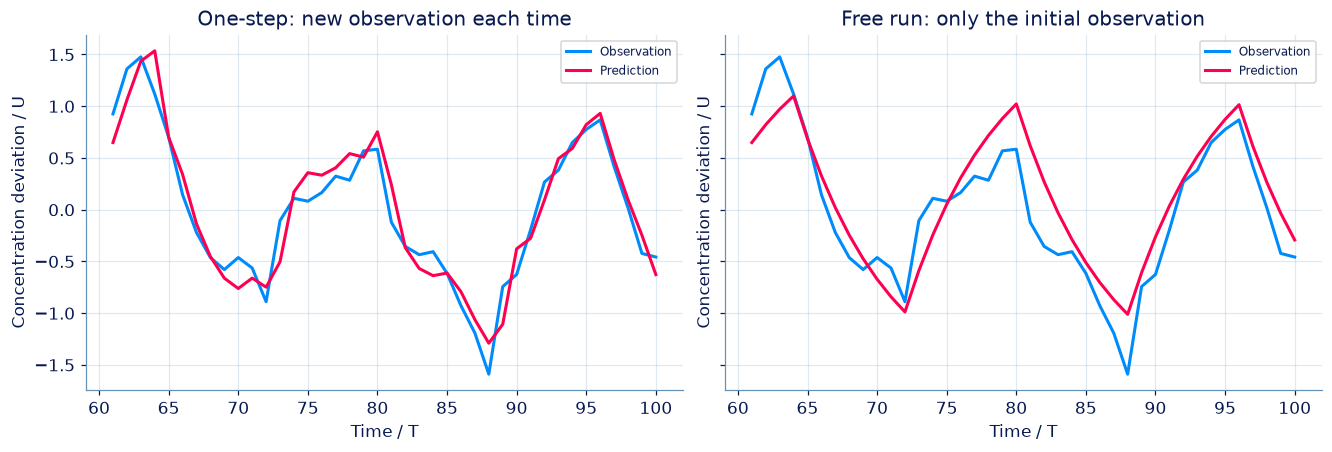

| 量 | 数值 |
| --- | --- |
| 估计 a | 0.86175 |
| 估计 b / (U/V) | 0.262755 |
| 一步 RMSE / U | 0.195943 |
| 自由运行 RMSE / U | 0.314205 |

In [4]:
streams=np.random.SeedSequence(6501).spawn(201)
rng=np.random.default_rng(streams[0]);u=np.where((np.arange(100)//8)%2,1.,-1.)
observed=np.zeros(101)
for n in range(100):observed[n+1]=.8*observed[n]+.3*u[n]+rng.normal(0,.2)
ahat,bhat=fit_arx(observed[:61],u[:60])
one,free=map(np.array,arx_predictions(ahat,bhat,observed[60:],u[60:]))
targets=observed[61:];times=np.arange(61,101)
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,prediction,title in [(axes[0],one,'One-step: new observation each time'),(axes[1],free,'Free run: only the initial observation')]:
    ax.plot(times,targets,color=BLUE,label='Observation')
    ax.plot(times,prediction,color=PINK,label='Prediction')
    ax.set(xlabel='Time / T',ylabel='Concentration deviation / U',title=title);ax.legend(fontsize=8)
plt.show()
display(Markdown(show_table(['量','数值'],[['估计 a',ahat],['估计 b / (U/V)',bhat],['一步 RMSE / U',np.sqrt(np.mean((one-targets)**2))],['自由运行 RMSE / U',np.sqrt(np.mean((free-targets)**2))]])))

再用 200 个独立子流考察测量误差偏差。每组直接从平稳初始分布（distribution）出发，保留 1000 次转移；过程标准差（standard deviation） 0.3 U、测量标准差 0.5 U、a=0.8。蓝色读取核验状态，玫红读取有噪观测；核验状态仅用于比较，不参与有噪回归。图中点为 200 组系数均值，误差条为组均值的 ±2 个蒙特卡洛（Monte Carlo）标准误（standard error），不是单个实验参数的置信区间（confidence interval）。

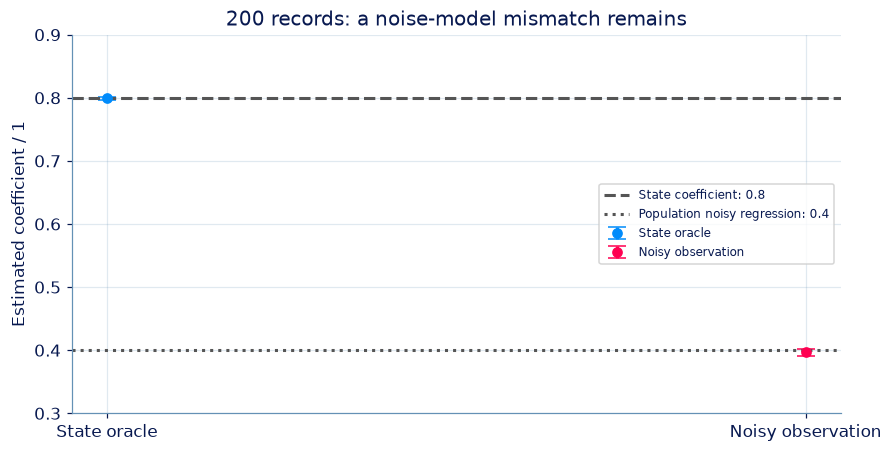

| 回归 | 200 组均值 | 组均值标准误 |
| --- | --- | --- |
| 核验状态 | 0.799025 | 0.00118823 |
| 有噪观测 | 0.396436 | 0.00248923 |

In [5]:
a_true=.8;process_sd=.3;measurement_sd=.5;state_variance=process_sd**2/(1-a_true**2)
estimates=[]
for seed in streams[1:]:
    rng=np.random.default_rng(seed);state=np.empty(1001);state[0]=rng.normal(0,np.sqrt(state_variance))
    for n in range(1000):state[n+1]=a_true*state[n]+rng.normal(0,process_sd)
    noisy=state+rng.normal(0,measurement_sd,len(state))
    estimates.append([np.dot(state[:-1],state[1:])/np.dot(state[:-1],state[:-1]),np.dot(noisy[:-1],noisy[1:])/np.dot(noisy[:-1],noisy[:-1])])
estimates=np.array(estimates);mean=estimates.mean(axis=0);se=estimates.std(axis=0,ddof=1)/np.sqrt(len(estimates))
attenuated=a_true*state_variance/(state_variance+measurement_sd**2)
fig,ax=plt.subplots(figsize=(8,4))
for i,(color,label) in enumerate([(BLUE,'State oracle'),(PINK,'Noisy observation')]):
    ax.errorbar(i,mean[i],yerr=2*se[i],fmt='o',capsize=6,color=color,label=label)
ax.axhline(a_true,color=GRAY,ls='--',label='State coefficient: 0.8')
ax.axhline(attenuated,color=GRAY,ls=':',label='Population noisy regression: 0.4')
ax.set(xticks=[0,1],xticklabels=['State oracle','Noisy observation'],ylabel='Estimated coefficient / 1',ylim=(.3,.9),title='200 records: a noise-model mismatch remains');ax.legend(fontsize=8)
plt.show()
display(Markdown(show_table(['回归','200 组均值','组均值标准误'],zip(['核验状态','有噪观测'],mean,se))))

## 结果解释

一步预测不断使用新观测，通常能修正前一拍的状态偏离；自由运行没有这一信息来源。测量噪声（measurement noise）实验中，两组均值分别接近 0.8 与 0.4，总体公式解释了差距。有限记录仍有随机波动和有限样本偏差；图上的误差条只描述这里 200 组均值的模拟精度，不覆盖真实系统的全部不确定性。

### 独立核对

手算短序列，并只修改未来观测，检查自由运行不受影响；在无扰动的独立轨迹上核对回归参数。最后用解析总体系数检查随机结果的尺度，不要求每次有限样本都等于理论极限（limit）。

In [6]:
short=arx_predictions(.5,1.,[0.,1.,2.,2.],[1.,1.,0.])
np.testing.assert_allclose(short,[[1,1.5,1],[1,1.5,.75]])
altered=arx_predictions(.5,1.,[0.,100.,-20.,2.],[1.,1.,0.])
np.testing.assert_allclose(altered[1],short[1])
assert arx_predictions(.5,1.,[4.],[])==([],[])
input_check=np.array([1.,-1.,1.,1.,0.]);state_check=[0.]
for v in input_check:state_check.append(.7*state_check[-1]+.4*v)
np.testing.assert_allclose(fit_arx(state_check,input_check),[.7,.4],atol=1e-14)
assert mean[0]>.7 and .3<mean[1]<.5
np.testing.assert_allclose(attenuated,.4)
print('索引、信息隔离、无噪参数与有条件偏差尺度检查通过。')

索引、信息隔离、无噪参数与有条件偏差尺度检查通过。


## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：一步预测与自由运行

参数（parameter）a、b已经由其他训练数据固定。对当前输入（input）与观测（observation）比较y[n+1]=a*y[n]+b*u[n]的一步预测（one-step-ahead prediction）和自由运行（free-run simulation），不能重新拟合。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    observed: list[float],
    inputs: list[float],
) -> tuple[list[float], list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 输出（output）的一拍反馈（feedback）系数。 | 1 |
| `b` | `float` | 输入到下一拍输出的增益（gain）。 | U/V |
| `observed` | `list[float]` | y[0]…y[N]，首项是两种预测共同初态。 | U |
| `inputs` | `list[float]` | u[0]…u[N−1]，u[n]作用于y[n+1]。 | V |

**返回值**

按以下顺序返回元组：(one_step, free_run)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `one_step` | `list[float]` | 预测y[1]…y[N]，每步使用上一拍实际观测。 | U |
| `free_run` | `list[float]` | 预测同样N个时刻，只使用初态和先前预测。 | U |

**计算规则**

一步：one_step[n]=a*observed[n]+b*inputs[n]；自由运行从current=observed[0]开始，每步current=a*current+b*u，再加入结果。两个结果都不含初态。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 0≤N≤30；observed长度为N+1，inputs长度为N；每项绝对值≤10；|a|≤1.2，|b|≤3。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 输出（output）的一拍反馈（feedback）系数。 | 0.5 | 1 |
| b | 输入到下一拍输出的增益（gain）。 | 1 | U/V |
| observed | y[0]…y[N]，首项是两种预测共同初态。 | [0.0, 1.0, 2.0, 2.0] | U |
| inputs | u[0]…u[N−1]，u[n]作用于y[n+1]。 | [1.0, 1.0, 0.0] | V |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.5
b = 1.0
observed = [0.0, 1.0, 2.0, 2.0]
inputs = [1.0, 1.0, 0.0]

result = solve(a, b, observed, inputs)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| one_step | 预测y[1]…y[N]，每步使用上一拍实际观测。 | [1.0, 1.5, 1.0] | U |
| free_run | 预测同样N个时刻，只使用初态和先前预测。 | [1.0, 1.5, 0.75] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, 1.5, 1.0], [1.0, 1.5, 0.75])
```

**样例解释**

一步预测 [1,1.5,1] U；自由运行 [1,1.5,0.75] U。第三步前者用实际y[2]=2，后者用自己的1.5。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：一步预测与自由运行](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-arx-predictions)

### 第 2 题 · 单项选择题：ARX回归的一行由什么组成

模型（model）y[n+1]=a*y[n]+b*u[n]+e[n+1]。拟合a、b时哪一行对应目标y[n+1]？

- **A.** 只取y[n+1]作为自己的解释变量。
- **B.** [y[n],u[n]]。
- **C.** [y[n+1],u[n+1]]。
- **D.** [a,b]。

[作答：ARX回归的一行由什么组成](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-arx-regressors)

### 第 3 题 · 多项选择题：两种预测用了同样信息吗

同一参数（parameter）、同一评估区间的一步RMSE很小，自由运行（free-run simulation）RMSE较大。哪些正确？

- **A.** 一步预测（one-step-ahead prediction）每拍可用新的观测（observation）校正，因此任务不同。
- **B.** 必须同时说明两种模式、初始化与指标时段。
- **C.** 一步好就必然证明长期自主模拟准确。
- **D.** 自由运行的误差可以随着递推积累。

[作答：两种预测用了同样信息吗](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-prediction-information)

### 第 4 题 · 多项选择题：最小二乘怎样受到观测噪声影响

真实x[n+1]=a*x[n]+b*u[n]，仪器只给y[n]=x[n]+v[n]，v为独立测量误差。哪些正确？

- **A.** 等效误差v[n+1]−a*v[n]与回归量y[n]共享v[n]。
- **B.** 所有叫ARX的拟合都自动一致。
- **C.** 独立创新进入状态（state）的模型（model）与此测量噪声（measurement noise）模型有不同假设。
- **D.** 直接回归y[n+1]对y[n]可能有误差变量偏差。

[作答：最小二乘怎样受到观测噪声影响](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-arx-noise-assumption)

### 第 5 题 · 单项选择题：输入延迟选错会怎样

真实输入（input）u[n−1]影响y[n+1]，却拟合成u[n]即时作用。哪项正确？

- **A.** 增加小数位可以把延迟（delay）变成增益（gain）。
- **B.** 训练误差最小足以消除结构选择风险。
- **C.** 只要求解器精度高，就自动修复延迟错误。
- **D.** 残差（residual）与滞后输入（lagged input）可能相关，需要比较有明确索引的候选结构。

[作答：输入延迟选错会怎样](http://127.0.0.1:8000/chapters/06-05-%E5%8A%A8%E6%80%81%E8%BE%A8%E8%AF%86%E3%80%81%E5%AE%9E%E9%AA%8C%E8%AE%BE%E8%AE%A1%E4%B8%8E%E9%AA%8C%E8%AF%81/practice/?question=p06-delay-structure)

**进一步阅读**

[Ljung《System Identification: Theory for the User》第二版资料页](https://www.rt.isy.liu.se/en/books/sysid/)：动态预测、模型结构与辨识的进一步学习入口；这里的标量偏差公式由协方差直接推导。